In [56]:
import pandas as pd
import pickle
import random
import numpy as np
import os
import itertools
from joblib import Parallel, delayed , parallel_backend
from collections import defaultdict
import math
import torch.nn as nn
import json

from Equations_Run_Combo_V_2 import *
import matplotlib.pyplot as plt


import pickle
with open('/Users/cs/Desktop/LSTM_ETF/short_dfs.pkl', 'rb') as f:
    loaded_dfs = pickle.load(f)

with open("/Users/cs/Desktop/LSTM_ETF/lagged_cache.pkl", "rb") as f:
    lagged_cache = pickle.load(f)


#/home/charifslmn/

In [57]:
def classify_severity_10_percent_pos(actual_value):
    """Classify actual values into severity categories"""
    if 0 < actual_value <= 0.05:
        return "Pos_low (0-0.05)"
    elif 0.05 < actual_value <= 0.1:
        return "Pos_high (0.05-0.1)"

    elif 0 > actual_value >= -0.05:
        return "Neg_low (-0.05) - 0"
    elif -0.05 > actual_value > -0.12:
        return "Neg_mid (-0.12) - (-0.05)"
    elif actual_value <= -0.12:
        return "Severe (<-0.12)"



def TP_FP_brackets_analysis(top_models ,brackets , mdoel_name : str ):
        
    # Count TP and FP for each bracket
    bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0})

    for score, entry in top_models:
        for pred_fold, actual_fold in zip(entry['all_preds'], entry['all_actuals']):
            for pred, actual in zip(pred_fold, actual_fold):
                if pred > 0.5:
                    for L, H in brackets:
                        if L < pred < H:
                            if actual > 0.5:
                                bracket_counts[f"{L}-{H}"]['TP'] += 1
                            else:
                                bracket_counts[f"{L}-{H}"]['FP'] += 1

    # Prepare data for plotting
    bracket_labels = sorted(bracket_counts.keys(), key=lambda x: float(x.split('-')[0]))
    tp_counts = [bracket_counts[b]['TP'] for b in bracket_labels]
    fp_counts = [bracket_counts[b]['FP'] for b in bracket_labels]

    # Create plot
    plt.figure(figsize=(4, 5))
    x = np.arange(len(bracket_labels))
    width = 0.35

    plt.bar(x - width/2, tp_counts, width, label='True Positives', color='green', alpha=0.7)
    plt.bar(x + width/2, fp_counts, width, label='False Positives', color='red', alpha=0.7)

    plt.xlabel('Confidence Brackets ')
    plt.ylabel('Count')
    plt.title(f'TP vs FP by Confidence Bracket  - {mdoel_name}')
    plt.xticks(x, bracket_labels, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



def TP_FP_brackets_severity_analysis(top, brackets , name : str ):

    # Count FP severity by bracket
    bracket_severity_counts = defaultdict(lambda: {
        "Pos_high (0.05-0.1)":0 ,
        "Pos_low (0-0.05)":0 , 
        "Neg_low (-0.05) - 0": 0 ,
        "Neg_mid (-0.12) - (-0.05)" : 0 ,
        "Severe (<-0.12)" : 0 })



    for score, entry in top:
        all_preds = entry['all_preds']
        all_actuals = entry['all_actuals']
        raw_actuals = entry['raw_actuals']
        
        # Flatten all arrays
        flat_preds = [p for fold in all_preds for p in fold]
        flat_actuals = [a for fold in all_actuals for a in fold]
        flat_raw_actuals = [r for fold in raw_actuals for r in fold]
        
        for p, a, raw in zip(flat_preds, flat_actuals, flat_raw_actuals):
            # Only process FALSE POSITIVES
            if p > 0.5 and a < 0.5:
                severity = classify_severity_10_percent_pos(raw)

                # print(f"Pred: {p:.3f}, Actual: {a:.3f}, Raw: {raw:.3f} => Severity: {severity}")
                
                # Find which bracket this prediction falls into
                for L, H in brackets:
                    if L < p < H:
                        bracket_severity_counts[f"{L}-{H}"][severity] += 1
                        break

    # Prepare data for plotting
    bracket_labels = sorted(bracket_severity_counts.keys(), key=lambda x: float(x.split('-')[0]))
    severity_categories = ["Pos_high (0.05-0.1)", "Pos_low (0-0.05)", "Neg_low (-0.05) - 0", "Neg_mid (-0.12) - (-0.05)", "Severe (<-0.12)"]

    # Create the stacked bar plot
    plt.figure(figsize=(4, 5))
    x = np.arange(len(bracket_labels))
    width = 0.8
    bottom = np.zeros(len(bracket_labels))

    colors = ['lightblue', 'lightgreen', 'yellow' , 'orange', 'red']

    for i, category in enumerate(severity_categories):
        counts = [bracket_severity_counts[b][category] for b in bracket_labels]
        plt.bar(x, counts, width, bottom=bottom, label=category, alpha=0.8, color=colors[i])
        bottom += counts

    plt.xlabel('Confidence Brackets')
    plt.ylabel('Count of False Positives')
    plt.title(f'False Positives by Confidence Bracket vs Actual Severity - {name}')
    plt.xticks(x, bracket_labels, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Add total counts and severity proportions on top
    for i, bracket in enumerate(bracket_labels):
        total = sum(bracket_severity_counts[bracket].values())
        severe_count = bracket_severity_counts[bracket]['Severe (<-0.12)']
        severe_proportion = (severe_count / total * 100) if total > 0 else 0
        
        plt.text(i, total + 0.5, f"{total}\n({severe_proportion:.0f}% severe)", 
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Print severity proportion analytics
    print("Severe Case Proportions by Confidence Bracket:")
    print("-" * 50)
    for bracket in bracket_labels:
        total = sum(bracket_severity_counts[bracket].values())
        severe_count = bracket_severity_counts[bracket]['Severe (<-0.12)']
        severe_proportion = (severe_count / total * 100) if total > 0 else 0
        
        print(f"{bracket}: {severe_proportion:.1f}% severe ({severe_count}/{total})")

    print("Severity Counts by Confidence Bracket:")
    print("-" * 50)
    for bracket in bracket_labels:
        print(f"{bracket}: {bracket_severity_counts[bracket]}")




{'binary_0_1_cutoff_ret_rate_percentage': 0.1, 'learning_rate': 0.0005, 'num_epochs': 150, 'batch_size': 50, 'use_bidirectional': False, 'lag': 6, 'input_size': 12, 'hidden_size': 55, 'num_layers': 2, 'use_monthly_dfs_only': True, 'use_binary_0_1_retRate': False, 'use_custom_loss_function_BCE_THRESH': False, 'use_custom_loss_function_BCE_THRESH_AND_SEVERITY': False, 'use_LOW_weights_for_BCE_custom_loss': True, 'pred_threshold_sigmoid01_up': None, 'use_binary_neg1_1': False, 'use_ret_rate': False, 'use_print_acc': False, 'use_dropout': False, 'use_class_weighting': False, 'is_deterministic': True, 'seed_num': 42, 'use_existing_lagged_data': True, 'use_dynamic_weights': False, 'use_binary_0_1_retRate_custom_neg': False, 'use_binary_0_1_retRate_custom_pos': True, 'POS_weight_multiplier': 0.7, 'use_rolling_fixed_train_size': False, 'use_existing_initial_weights': False, 'state_dict': None, 'use_USO_wticoncat_predictor_WEEKLY_END_MO': False, 'use_UCO_wticoncat_predictor_WEEKLY_END_MO': Fals

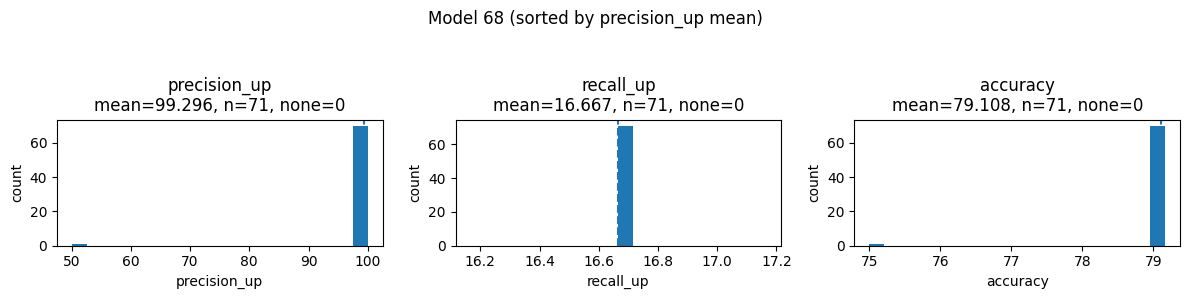

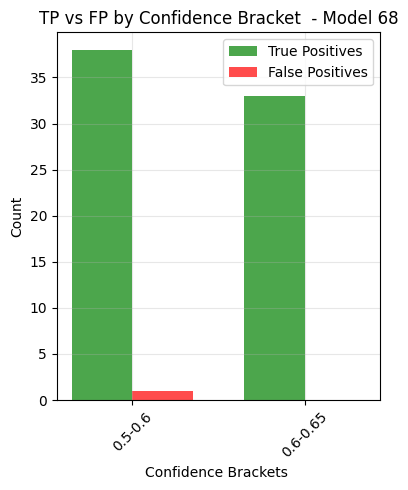

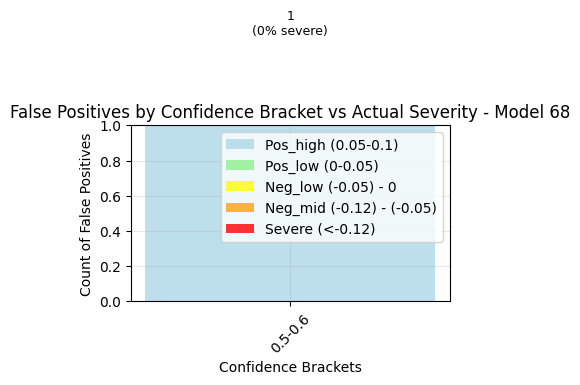

Severe Case Proportions by Confidence Bracket:
--------------------------------------------------
0.5-0.6: 0.0% severe (0/1)
Severity Counts by Confidence Bracket:
--------------------------------------------------
0.5-0.6: {'Pos_high (0.05-0.1)': 1, 'Pos_low (0-0.05)': 0, 'Neg_low (-0.05) - 0': 0, 'Neg_mid (-0.12) - (-0.05)': 0, 'Severe (<-0.12)': 0}


In [68]:
with open('/Users/cs/Desktop/top_70_DIST_DISC_GS_20_01_to_21_12_chunk_1_22_10percentPOS_Vset_HOD.json') as f_json:

    results_dist_disc = json.load(f_json)   # Load the JSON data



brackets = [(0.5, 0.6), (0.6, 0.65), (0.65, 0.7), (0.7, 0.75), 
            (0.75, 0.8), (0.8, 0.85), (0.85, 0.9), (0.9, 0.95), (0.95, 1)]

metrics = ["precision_up", "recall_up", "accuracy"]


# ---- collect per-model data and compute precision_up mean for ordering ----
model_summaries = []  # (prec_mean, combo_idx, collected_dict, parameters, per_seed)

for model in results_dist_disc:
    combo_idx = model["combo_index"]
    parameters = model["combo"]
    per_seed = model["per_seed_all_results"]

    collected = {k: [] for k in metrics}
    for run in per_seed:
        om = run["result_entry"]["cv_sets"]["overall_metrics"]
        for k in metrics:
            v = om[k]
            try:
                collected[k].append(float(v))
            except (TypeError, ValueError):
                collected[k].append(None)

    vals_prec = [x for x in collected["precision_up"] if isinstance(x, (int, float)) and not (isinstance(x, float) and math.isnan(x))]
    prec_mean = float(np.mean(vals_prec)) if vals_prec else float("nan")

    # ⬇️ add per_seed in the tuple
    model_summaries.append((prec_mean, combo_idx, collected, parameters, per_seed))

# sort as before
model_summaries.sort(key=lambda t: (-t[0]) if not math.isnan(t[0]) else float("inf"))

LENGTH = 1
# ---- plot in the sorted order ----
for prec_mean, combo_idx, collected, parameters, per_seed in model_summaries[:LENGTH]:
    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), squeeze=False)
    axes = axes[0]

    print(parameters)

    for ax, k in zip(axes, metrics):
        vals = [x for x in collected[k] if isinstance(x, (int, float)) and not (isinstance(x, float) and math.isnan(x))]
        none_cnt = len(collected[k]) - len(vals)

        if vals:
            mean_val = float(np.mean(vals))
            ax.hist(vals, bins=20)
            ax.axvline(mean_val, linestyle="--")
            ax.set_xlabel(k)
            ax.set_ylabel("count")
            ax.set_title(f"{k}\nmean={mean_val:.3f}, n={len(vals)}, none={none_cnt}")
        else:
            ax.text(0.5, 0.5, f"No data\nnone={none_cnt}", ha="center", va="center")
            ax.set_xticks([]); ax.set_yticks([]); ax.set_title(k)

    fig.suptitle(f"Model {combo_idx} (sorted by precision_up mean)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    # =================== NEW: per-model correlation-threshold + severity plots ===================

    # Recycle your functions by making a "top-like" list from this model's seeds
    # Each item: (score_unused, entry=result_entry)
    top_like_for_this_model = [(0.0, run["result_entry"]) for run in per_seed]

    # Correlation / confidence bracket plot for THIS model
    TP_FP_brackets_analysis(top_like_for_this_model, brackets, f"Model {combo_idx}")

    # Severity plot for THIS model
    TP_FP_brackets_severity_analysis(top_like_for_this_model, brackets, f"Model {combo_idx}")






#### Models Chosen Thresh
# models:
 
# 68 - seeds high  seeds low
# 32 - seeds high 6963  seeds low 2703
# 43 - seeds high 11794 seeds low 30341
# 58- seeds high 26058 seeds low 
# 6- seeds high 1719 seeds low 3556
# 0 - seeds high 42 seeds low 4198
# 57 - seeds high 14577  seeds low
# --- 
# 31- seeds high 35229 seeds low                9118high
# 60 - seeds high 4956  seeds low 48198


prec_brackets = [(65, 70), (70, 75), (75, 80), (80, 85), (85, 90), (90, 95), (95, 100)]
models_combo_index = [68, 32, 43, 58, 31, 6, 0, 57, 31, 60]

buckets = {}  # buckets["combo_idx_<idx>"][seed][(L,H)] = [ {precision_up, result}, ... ]

for model in results_dist_disc:
    combo_idx = model["combo_index"]
    if combo_idx not in models_combo_index:
        continue

    combo_key = f"combo_idx_{combo_idx}"
    combo_dict = buckets.setdefault(combo_key, {})  # dict per seed

    for res in model["per_seed_all_results"]:
        seed = str(res.get("seed"))
        prec = res["result_entry"]["cv_sets"]["overall_metrics"].get("precision_up")
        if prec is not None:


            # place into first matching bracket (inclusive on lower, exclusive on upper; last bracket includes upper)
            for idx, (L, H) in enumerate(prec_brackets):
                in_bracket = (L <= prec < H) if idx < len(prec_brackets) - 1 else (L <= prec <= H)
                if in_bracket:
                    seed_dict = combo_dict.setdefault(seed, {})
                    lst = seed_dict.setdefault((L, H), [])
                    lst.append({"precision_up": prec, "result": res})
                    break


In [102]:
# Modified function to store TP and FP counts for each seed
def select_models_by_criteria(results_data, 
                             mean_precision_range=(0, 100),
                             seed_precision_range=(0, 100),
                             seed_recall_range=(0, 100),
                             min_seeds_per_model=1,
                             max_models_to_return=10,
                             max_zero_precision_seeds=None,
                             min_ratio_difference=None,
                             random_seed=None):
    
    if random_seed is not None:
        random.seed(random_seed)

    brackets = [(0.5, 0.7), (0.7, 1.0)]
    model_summaries = []

    for model in results_data:
        combo_idx = model.get("combo_index", None)
        # combo_number_fallback = None
        # if combo_idx is None and model.get("per_seed_all_results"):
        #     combo_number_fallback = model["per_seed_all_results"][0]["result_entry"].get("combo_number")
        #     if isinstance(combo_number_fallback, int):
        #         combo_idx = combo_number_fallback - 1
        # if combo_idx is None:
        #     combo_idx = -1

        parameters = model.get("combo", {})
        per_seed = model.get("per_seed_all_results", [])

        zero_precision_count = 0
        bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0, 'TN': 0, 'FN': 0})
        seed_records = []

        for run in per_seed:
            re = run["result_entry"]
            om = re["cv_sets"]["overall_metrics"]

            seed_num = run.get("seed", None)


            prec = om.get("precision_up")
            rec = om.get("recall_up")
            if isinstance(prec, (int, float)) and not math.isnan(prec):
                prec = float(prec)
                if prec == 0:
                    zero_precision_count += 1
            else:
                prec = None

            if isinstance(rec, (int, float)) and not math.isnan(rec):
                rec = float(rec)
            else:
                rec = None

            # Store TP and FP counts for each bracket per seed
            seed_bracket_counts = defaultdict(lambda: {'TP': 0, 'FP': 0, 'TN': 0, 'FN': 0})
            seed_total_tp = 0
            seed_total_fp = 0

            for pred_fold, actual_fold in zip(re["all_preds"], re["all_actuals"]):
                for pred, actual in zip(pred_fold, actual_fold):
                    true_positive  = (actual > 0.5) and (pred >= 0.5)
                    false_positive = (actual <= 0.5) and (pred >= 0.5)
                    true_negative  = (actual <= 0.5) and (pred < 0.5)
                    false_negative = (actual > 0.5) and (pred < 0.5)

                    assigned = False
                    for L, H in brackets:
                        if L <= pred < H:
                            assigned = True
                            key = f"{L}-{H}"
                            if true_positive:
                                bracket_counts[key]['TP'] += 1
                                seed_bracket_counts[key]['TP'] += 1
                                seed_total_tp += 1
                            elif false_positive:
                                bracket_counts[key]['FP'] += 1
                                seed_bracket_counts[key]['FP'] += 1
                                seed_total_fp += 1
                            elif true_negative:
                                bracket_counts[key]['TN'] += 1
                                seed_bracket_counts[key]['TN'] += 1
                            elif false_negative:
                                bracket_counts[key]['FN'] += 1
                                seed_bracket_counts[key]['FN'] += 1
                    if not assigned:
                        pass

            seed_fp_tp_ratios = {}
            for key, counts in seed_bracket_counts.items():
                tp, fp = counts['TP'], counts['FP']
                denom = tp + fp
                seed_fp_tp_ratios[key] = (fp / denom) if denom > 0 else float("nan")

            seed_records.append({
                "seed_num": seed_num,
                "precision": prec,
                "recall": rec,
                "seed_bracket_counts": dict(seed_bracket_counts),
                "seed_fp_tp_ratios": seed_fp_tp_ratios,
                "seed_total_tp": seed_total_tp,  # Store total TP for seed
                "seed_total_fp": seed_total_fp,  # Store total FP for seed
                "seed_raw": run,
            })

        non_none_precs = [r["precision"] for r in seed_records if r["precision"] is not None]
        mean_precision = float(np.mean(non_none_precs)) if non_none_precs else float("nan")

        fp_tp_ratios = {}
        for key, counts in bracket_counts.items():
            tp, fp = counts['TP'], counts['FP']
            denom = tp + fp
            fp_tp_ratios[key] = (fp / denom) if denom > 0 else float("nan")

        ratio_difference = None
        if "0.7-1.0" in fp_tp_ratios and "0.5-0.7" in fp_tp_ratios:
            rh, rl = fp_tp_ratios["0.7-1.0"], fp_tp_ratios["0.5-0.7"]
            if not math.isnan(rh) and not math.isnan(rl):
                ratio_difference = rl - rh

        model_summaries.append({
            "combo_index": combo_idx,
            # "combo_number": combo_number_fallback,
            "parameters": parameters,
            "mean_precision": mean_precision,
            "zero_precision_count": zero_precision_count,
            "total_seeds": len(seed_records),
            "seed_records": seed_records,
            "bracket_counts": dict(bracket_counts),
            "fp_tp_ratios": fp_tp_ratios,
            "ratio_difference": ratio_difference,
        })

    filtered_models = []
    min_mean_prec, max_mean_prec = mean_precision_range
    min_seed_prec, max_seed_prec = seed_precision_range
    min_seed_rec,  max_seed_rec  = seed_recall_range

    for m in model_summaries:
        if not (min_mean_prec <= (m["mean_precision"] if not math.isnan(m["mean_precision"]) else -float("inf")) <= max_mean_prec):
            continue

        if max_zero_precision_seeds is not None and m["zero_precision_count"] > max_zero_precision_seeds:
            continue

        if (min_ratio_difference is not None) and (m["ratio_difference"] is not None):
            if m["ratio_difference"] < min_ratio_difference:
                continue
        elif (min_ratio_difference is not None) and (m["ratio_difference"] is None):
            continue

        valid_seeds = []
        for idx, r in enumerate(m["seed_records"]):
            prec, rec = r["precision"], r["recall"]
            if prec is None or rec is None:
                continue
            if (min_seed_prec <= prec <= max_seed_prec) and (min_seed_rec <= rec <= max_seed_rec):
                valid_seeds.append({
                    "seed_order_index": idx,
                    "seed_num": r["seed_num"],
                    "precision": prec,
                    "recall": rec,
                    "seed_bracket_counts": r["seed_bracket_counts"],
                    "seed_fp_tp_ratios": r["seed_fp_tp_ratios"],
                    "seed_total_tp": r["seed_total_tp"],  # Include TP count
                    "seed_total_fp": r["seed_total_fp"],  # Include FP count
                })

        if len(valid_seeds) >= min_seeds_per_model:
            filtered_models.append({
                "combo_index": m["combo_index"],
                # "combo_number": m["combo_number"],
                "parameters": m["parameters"],
                "mean_precision": m["mean_precision"],
                "valid_seeds_count": len(valid_seeds),
                "valid_seeds": valid_seeds,
                "total_seeds": m["total_seeds"],
                "zero_precision_count": m["zero_precision_count"],
                "bracket_counts": m["bracket_counts"],
                "fp_tp_ratios": m["fp_tp_ratios"],
                "ratio_difference": m["ratio_difference"],
            })

    n_pick = min(max_models_to_return, len(filtered_models))
    selected_models = random.sample(filtered_models, n_pick) if n_pick > 0 else []

    output = []
    for m in selected_models:
        output.append({
            "combo_index": m["combo_index"],
            # "combo_number": m["combo_number"],
            "parameters": m["parameters"],
            "mean_precision": m["mean_precision"],
            "valid_seeds_count": m["valid_seeds_count"],
            "total_seeds": m["total_seeds"],
            "zero_precision_count": m["zero_precision_count"],
            "bracket_counts": m["bracket_counts"],
            "fp_tp_ratios": m["fp_tp_ratios"],
            "ratio_difference": m["ratio_difference"],
            "selected_seeds": [
                {
                    "seed_num": s["seed_num"],
                    "seed_order_index": s["seed_order_index"],
                    "precision": s["precision"],
                    "recall": s["recall"],
                    "seed_bracket_counts": s["seed_bracket_counts"],
                    "seed_fp_tp_ratios": s["seed_fp_tp_ratios"],
                    "seed_total_tp": s["seed_total_tp"],  # Include in output
                    "seed_total_fp": s["seed_total_fp"],  # Include in output
                }
                for s in m["valid_seeds"]
            ]
        })

    return output



# models to output

# mean prec model           - low 51 - 70 high 70 - 100
# prec seed                 - low 51 - 70 high 70 - 100
# ratio diff                - None High .1 


# Run the function
selected_models = select_models_by_criteria(
    results_dist_disc,
    mean_precision_range=(51, 70), ### mean model range 
    seed_precision_range=(51, 70),
    seed_recall_range=(1, 100),
    min_seeds_per_model=1,
    max_zero_precision_seeds=10,
    min_ratio_difference=0.04,
    max_models_to_return=20,
    random_seed=42
)

# Summary of Selected Models with TP and FP counts
print(f"Total models selected: {len(selected_models)}")
print("\n" + "="*80)

for i, model in enumerate(selected_models):
    print(f"\nMODEL #{i+1}")
    print(f"Combo Index: {model['combo_index']}")
    # print(f"Combo Number: {model['combo_number']}")
    print(f"Mean Precision: {model['mean_precision']:.2f}%")
    print(f"Valid Seeds: {model['valid_seeds_count']}/{model['total_seeds']}")
    print(f"Zero Precision Seeds: {model['zero_precision_count']}")
    
    # Print model-level bracket statistics
    print("Model Bracket Statistics:")
    for bracket, counts in model['bracket_counts'].items():
        tp, fp = counts['TP'], counts['FP']
        ratio = (fp / (tp + fp)) * 100 if (tp + fp) > 0 else float('nan')
        print(f"  {bracket}: TP={tp}, FP={fp}, FP/(TP+FP) = {ratio:.1f}%")
    
    if model['ratio_difference'] is not None:
        print(f"Ratio Difference (Low-High): {model['ratio_difference']:.3f}")
    
    # Print seed details with TP and FP counts
    print("Selected Seeds:")
    for seed in model['selected_seeds']:
        print(f"  Seed {seed['seed_num']}: Precision={seed['precision']:.2f}%, Recall={seed['recall']:.2f}%")
        print(f"    Total TP: {seed['seed_total_tp']}, Total FP: {seed['seed_total_fp']}")
        
        # Print bracket-level details for each seed
        for bracket, counts in seed['seed_bracket_counts'].items():
            tp, fp = counts['TP'], counts['FP']
            ratio = (fp / (tp + fp)) * 100 if (tp + fp) > 0 else float('nan')
            print(f"    {bracket}: TP={tp}, FP={fp}, FP/(TP+FP) = {ratio:.1f}%")





Total models selected: 8


MODEL #1
Combo Index: 24
Mean Precision: 58.38%
Valid Seeds: 21/71
Zero Precision Seeds: 0
Model Bracket Statistics:
  0.5-0.7: TP=19, FP=29, FP/(TP+FP) = 60.4%
  0.7-1.0: TP=139, FP=100, FP/(TP+FP) = 41.8%
Ratio Difference (Low-High): 0.186
Selected Seeds:
  Seed 12142: Precision=60.00%, Recall=50.00%
    Total TP: 3, Total FP: 2
    0.5-0.7: TP=1, FP=0, FP/(TP+FP) = 0.0%
    0.7-1.0: TP=2, FP=2, FP/(TP+FP) = 50.0%
  Seed 8942: Precision=60.00%, Recall=50.00%
    Total TP: 3, Total FP: 2
    0.7-1.0: TP=3, FP=2, FP/(TP+FP) = 40.0%
  Seed 25944: Precision=66.67%, Recall=33.33%
    Total TP: 2, Total FP: 1
    0.7-1.0: TP=2, FP=1, FP/(TP+FP) = 33.3%
  Seed 32299: Precision=66.67%, Recall=33.33%
    Total TP: 2, Total FP: 1
    0.5-0.7: TP=1, FP=1, FP/(TP+FP) = 50.0%
    0.7-1.0: TP=1, FP=0, FP/(TP+FP) = 0.0%
  Seed 18721: Precision=66.67%, Recall=33.33%
    Total TP: 2, Total FP: 1
    0.7-1.0: TP=2, FP=1, FP/(TP+FP) = 33.3%
  Seed 3321: Precision=60.00%, Reca

In [104]:
# mean prec model           - low 51 - 70 high 70 - 100
# prec seed                 - low 51 - 70 high 70 - 100
# ratio diff                - None High .1 

param_map = {
    "mean_precision_range": [(51, 70), (70, 100) ],  # Example range for mean precision
    "seed_precision_range": [(51, 70) , (70, 100)],  # Example range for seed precision
    "seed_recall_range": [(1, 100)],     # Example range for seed recall
    "min_seeds_per_model": [1],
    "max_models_to_return": [20],
    "max_zero_precision_seeds": [10],
    "min_ratio_difference": [0.1 , None],
    "random_seed": [42]
}


keys , values = zip(*param_map.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

len(combinations)  # Show first 3 combinations for brevity

8

In [ ]:
# Modified function to store TP and FP counts for each seed
def select_models_by_criteria(results_data, 
                             mean_precision_range=(0, 100),
                             seed_precision_range=(0, 100),
                             seed_recall_range=(0, 100),
                             min_seeds_per_model=1,
                             max_models_to_return=10,
                             max_zero_precision_seeds=None,
                             min_ratio_difference=None,
                             random_seed=None):


In [ ]:
###                             FIRST

import math 
from joblib import parallel_backend , Parallel , delayed 
import random 


######    GS 


param_grid = {
                      "binary_0_1_cutoff_ret_rate_percentage" : [0.1],
    "learning_rate": [0.05, 0.005, 0.0005 , 0.00005],
    "num_epochs": [ 70, 150, 300, 700],
    "batch_size": [10, 30, 50, 70],
    "use_bidirectional": [False],
    "lag": [ 2, 3, 6 , 8],
    "input_size": [12],
    "hidden_size": [ 12, 20, 35, 55],
    "num_layers": [1, 2, 4 , 6],
                                            "use_monthly_dfs_only": [True],
    
                                            "use_binary_0_1_retRate": [False],

                "use_custom_loss_function_BCE_THRESH": [False , True], # NEW NEW NEW
                "use_custom_loss_function_BCE_THRESH_AND_SEVERITY": [False], # NEW NEW NEW
                "use_LOW_weights_for_BCE_custom_loss": [True], # NEW NEW NEW
                "pred_threshold_sigmoid01_up": [None], # NEW NEW NEW


    "use_binary_neg1_1": [False],  
    "use_ret_rate": [False],       
    "use_print_acc": [False],      
    "use_dropout": [False],  
    # "iter_per_valSET": [1],        
                                             "use_class_weighting": [True, False],

    "is_deterministic": [True],     "seed_num": [42],       
    "use_existing_lagged_data": [True],'use_dynamic_weights' : [False] ,


    'use_binary_0_1_retRate_custom_neg' : [False] ,
    'use_binary_0_1_retRate_custom_pos' : [True] ,
    

    'POS_weight_multiplier' : [  .1 ,  .7 ,  1  ,  1.3 , 1.5   ] , ## 24 vals is val set, 3 units per ser fi folds are 8 
    'use_rolling_fixed_train_size' : [False],
    'use_existing_initial_weights': [False], 
    'state_dict' : [None],

    "use_USO_wticoncat_predictor_WEEKLY_END_MO" : [False] , "use_UCO_wticoncat_predictor_WEEKLY_END_MO" : [False] , ### NEW NEW
    "use_HUC_wticoncat_predictor_WEEKLY_END_MO" : [False] , "use_HOD_wticoncat_predictor_WEEKLY_END_MO" : [True] , ### HOD 
    "use_CRUD_wticoncat_predictor_WEEKLY_END_MO" : [False] , "use_SCO_wticoncat_predictor_WEEKLY_END_MO" : [False] ,

                    'train_start_month'  : ["2004-01" , "2008-01"],
                    'val_start_month'  : ['2021-01'] ,    # test_start_month = '2022-01' ; test_end_month = '2022-12' 
                    'val_end_month'  : ['2022-12'] ,
                    'num_preds_per_fold' : [3] , 

  } # NEW NEW NEW

# --- Prepare all combinations ---
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]


In [101]:
list(itertools.product(*values))

dict(zip(('k1' , 'k2') ,  [4,5]))

{'k1': 4, 'k2': 5}

In [ ]:
def select_models_by_criteria(results_data, 
                             mean_precision_range=(0, 100),
                             seed_precision_range=(0, 100),
                             seed_recall_range=(0, 100),
                             min_seeds_per_model=1,
                             max_models_to_return=10,
                             max_zero_precision_seeds=None,
                             min_ratio_difference=None,
                             random_seed=None)


param_dict = {

    
}